# Assignment 2 - Poject 7 Mixed Precision Training Strategy for VAE and VQ-VAE


## Description
Variational Autoencoders (VAE) and Vector Quantized Variational Autoencoders (VQ-VAE) are powerful generative models used in the field of deep learning for unsupervised learning tasks. This project aims to compare the performance of these models on three benchmark datasets: CIFAR-10, MNIST, and Fashion-MNIST. A key aspect of this comparison will be the use of normal and mixed precision training approaches, which have implications for training efficiency and model accuracy.

### Objectives

 - Implement VAE and VQ-VAE models in a deep learning framework
 - Train and evaluate these models on CIFAR-10, MNIST, and Fashion-MNIST datasets
 - Compare the performance of each model using normal and mixed precision training methods.
- Analyze the effects of precision training on the efficiency and accuracy of the models.

### notes on approach - A

- implimentation
    - VAE and VQ-VAE
- train both on each dataset
- comparison
    - mixed vs normal precision training
- analysis 
    - generation quality and reconstruction quality
    - training efficency
    - accuacay and preformance trade-offs
    

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os
import time
import pathlib as Path
import sys
import pandas as pd
from tqdm import tqdm
import json


import torchvision.utils as vutils
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [2]:
DATA_DIR = "./data"
OUTPUT_DIR = "./outputs"

BATCH_SIZE = 128
NUM_WORKERS = 2
LEARNING_RATE = 1e-3
LATENT_DIM = 128
dev_EPOCHS = 1
prod_EPOCHS = 100

# VQ specific variables
hidden_channels = 400

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Data Functions

In [3]:

def get_datasets(data_dir="./data", dataset_name="mnist"):
    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    if dataset_name == "mnist":
        train_set = datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 1, 28

    elif dataset_name == "fashion-mnist":
        train_set = datasets.FashionMNIST(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.FashionMNIST(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 1, 28

    elif dataset_name == "cifar10":
        train_set = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 3, 32

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    return train_set, test_set, in_channels, input_size

def get_dataloaders(data_dir="./data", dataset_name="mnist", batch_size=128, num_workers=2):
    train_set, test_set, in_channels, input_size = get_datasets(data_dir, dataset_name)

    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True
    )
    test_loader = DataLoader(
        test_set, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True
    )

    return train_loader, test_loader, in_channels, input_size

def show_batch(images, n=8, title="Batch"):
    images = images[:n].cpu()
    grid = vutils.make_grid(images, nrow=n, padding=2)
    plt.figure(figsize=(n * 1.5, 2))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray" if images.shape[1] == 1 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [4]:
#Make sure GPU torch is instaled and available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
#Check if GPU is available and set device accordingly
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [5]:
mnist_train, mnist_test, mnist_in_channels, mnist_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
fashion_mnist_train, fashion_mnist_test, fashion_mnist_in_channels, fashion_mnist_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="fashion-mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
cifar10_train, cifar10_test, cifar10_in_channels, cifar10_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="cifar10",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.12MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.99MB/s]
100%|██████████| 26.4M/26.4M [00:01<00:00, 17.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 275kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.04MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.17MB/s]
100%|██████████| 170M/170M [00:02<00:00, 75.9MB/s]


torch.Size([128, 1, 28, 28]) torch.Size([128])


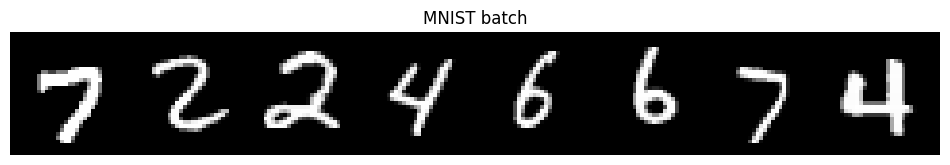

torch.Size([128, 1, 28, 28]) torch.Size([128])


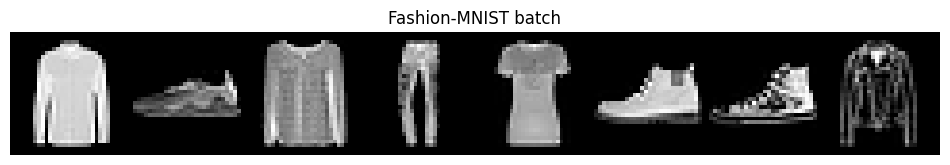

torch.Size([128, 3, 32, 32]) torch.Size([128])


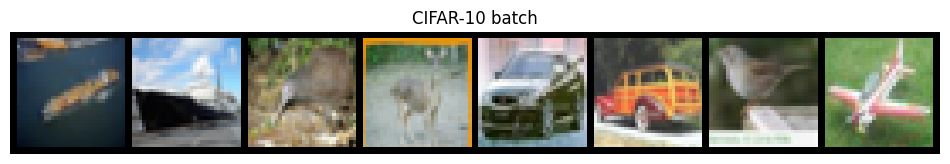

In [6]:
mnist_images, labels = next(iter(mnist_train))
fashion_mnist_images, labels1 = next(iter(fashion_mnist_train))
cifar10_images, labels2 = next(iter(cifar10_train))

print(mnist_images.shape, labels.shape)
show_batch(mnist_images, title="MNIST batch")
print(fashion_mnist_images.shape, labels1.shape)
show_batch(fashion_mnist_images, title="Fashion-MNIST batch")
print(cifar10_images.shape, labels2.shape)
show_batch(cifar10_images, title="CIFAR-10 batch")

# VAE implementation

iets


In [7]:
class VAE(nn.Module):
    """
    Standard Variational Autoencoder using Linear (Fully Connected) layers.
    """
    def __init__(self, input_dim=784, hidden_channels=400, latent_dim=32):
        super(VAE, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_channels = hidden_channels
        self.latent_dim = latent_dim

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_channels) #input to hidden
        self.enc_fc2 = nn.Linear(hidden_channels, hidden_channels) #hidden to hidden

        # the encoder outputs the mean and log variance for the latent space
        self.enc_mean = nn.Linear(hidden_channels, latent_dim) #hidden to mean
        self.enc_logvar = nn.Linear(hidden_channels, latent_dim) #hidden to logvar

        # Decoder
        self.dec_fc1 = nn.Linear(latent_dim, hidden_channels) #latent to hidden
        self.dec_fc2 = nn.Linear(hidden_channels, hidden_channels) #hidden to hidden
        self.dec_output = nn.Linear(hidden_channels, input_dim) #hidden to output

        self.leaky_relu = nn.LeakyReLU(0.2) #LeakyReLU activation function


    def encode(self, x):
        """Encodes the input into the latent space, returning the mean and log variance."""
        h = self.leaky_relu(self.fc1(x))
        h = self.leaky_relu(self.enc_fc2(h))
        mean = self.enc_mean(h)
        logvar = self.enc_logvar(h)
        return mean, logvar
    
    def reparameterize(self, mean, logvar):
        """Applies reparameterization trick z = mean + std * eps, where eps ~ N(0, 1)
        This allows backpropagation through the stochastic sampling process."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + std * eps
    

    def decode(self, z):
        """Decodes the latent variable back to the input space."""
        h = self.leaky_relu(self.dec_fc1(z))
        h = self.leaky_relu(self.dec_fc2(h))
        x_hat = torch.sigmoid(self.dec_output(h)) #sigmoid to get output in [0, 1]
        return x_hat
    
    def forward(self, x):
        # Flatten the input image to a vector
        BATCH_SIZE, C, H, W = x.size() #C = channels, H = height, W = width
        x_flat = x.view(BATCH_SIZE, -1) # Flatten the image to a vector

        # Encode the input to get mean and log variance
        mean, logvar = self.encode(x_flat)

        # Sample from the distribution using the reparameterization trick
        z = self.reparameterize(mean, logvar)

        # Decode the latent variable to reconstruct the input
        x_hat = self.decode(z)

        #reshape the output back to the original image shape
        x_hat = x_hat.view(BATCH_SIZE, C, H, W)
        return x_hat, mean, logvar


class ConvVAE(nn.Module):
    """
    Convolutional Variational Autoencoder for complex image datasets.
    """
    def __init__(self, in_channels, input_size, latent_dim=128, dataset_name="mnist"):
        super(ConvVAE, self).__init__()
        
        self.latent_dim = latent_dim
        self.dataset_name = dataset_name.lower()

        # ==========================================
        # 1. Input Size Type-Check
        # ==========================================
        # If your dataloader returns an int (e.g., 28), convert it to (28, 28)
        if isinstance(input_size, int):
            self.img_height = input_size
            self.img_width = input_size
        else:
            self.img_height = input_size[0]
            self.img_width = input_size[1]


        # ==========================================
        # ENCODER (Conv2d downsamples the image)
        # ==========================================
        # Formula for output size: [(W - Kernel + 2*Pad) / Stride] + 1
        self.enc_conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.leaky_relu = nn.LeakyReLU(0.2)
        
        # --- Dynamic Dimension Calculation ---
        # We pass a dummy tensor of the correct shape through the conv layers 
        # to figure out exactly how many features we need to flatten!
        dummy_x = torch.zeros(1, in_channels, self.img_height, self.img_width)
        dummy_out = self.enc_conv2(self.enc_conv1(dummy_x))
        
        # Save the shape before flattening so the decoder knows how to unflatten it later
        self.conv_shape = dummy_out.shape[1:] 
        self.flattened_size = dummy_out.numel()
        # -------------------------------------
        
        # Latent space mappings
        self.enc_mean = nn.Linear(self.flattened_size, latent_dim)
        self.enc_logvar = nn.Linear(self.flattened_size, latent_dim)
        
        # ==========================================
        # DECODER (ConvTranspose2d upsamples the image)
        # ==========================================
        self.dec_fc = nn.Linear(latent_dim, self.flattened_size)
        self.dec_conv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec_conv2 = nn.ConvTranspose2d(32, in_channels, kernel_size=3, stride=2, padding=1, output_padding=1)

    def encode(self, x):
        h = self.leaky_relu(self.enc_conv1(x))
        h = self.leaky_relu(self.enc_conv2(h))
        
        # Flatten for the linear layer
        h_flat = h.view(h.size(0), -1)
        mean = self.enc_mean(h_flat)
        logvar = self.enc_logvar(h_flat)
        return mean, logvar
        
    def reparameterize(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + std * eps
        
    def decode(self, z):
        # 1. Map latent vector back to the flattened spatial size
        h = self.leaky_relu(self.dec_fc(z))
        
        # 2. Reshape back to 3D tensor (Channels, Height, Width)
        h = h.view(h.size(0), *self.conv_shape)
        
        # 3. Upsample back to original image size
        h = self.leaky_relu(self.dec_conv1(h))
        
        # No ReLU on the final output, use Sigmoid (for MNIST/Fashion) or Tanh (if CIFAR is normalized -1 to 1)
        if self.dataset_name == "cifar10":
            x_hat = torch.tanh(self.dec_conv2(h))
        else:
            x_hat =  self.dec_conv2(h)#torch.sigmoid(self.dec_conv2(h))
        return x_hat

    def forward(self, x):
        # Notice we NO LONGER flatten the input 'x' here! It stays as a 2D image.
        mean, logvar = self.encode(x)
        z = self.reparameterize(mean, logvar)
        x_hat = self.decode(z)
        
        return x_hat, mean, logvar

In [8]:
# Loss function for VAE: Reconstruction loss + KL divergence
def vae_loss(reconstructed_x, x_orig, mean, logvar, dataset_name):
    """
    Computes the VAE loss, dynamically selecting the reconstruction 
    loss based on the dataset properties.
    """
    # 1. Reconstruction Loss
    if dataset_name.lower() == "cifar10":
        # MSE is standard for continuous RGB data
        recon_loss = F.mse_loss(reconstructed_x, x_orig, reduction='sum')
    else:
        # BCE is standard for normalized grayscale data [0, 1] (MNIST/Fashion-MNIST)
        recon_loss = F.binary_cross_entropy_with_logits(reconstructed_x, x_orig, reduction='sum')

    # 2. KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    
    return recon_loss + KLD, recon_loss, KLD

def train_vae(model, train_loader, epochs, optimizer, device, dataset_name, use_mixed_precision=False):
    """Trains the VAE model and returns the training history."""

    startTime = time.perf_counter()
    model.train()
    history = {"train_loss": [], "bce_loss": [], "kld_loss": [], "model":model, "optimizer": optimizer, "training_time": None }

    # 1. Initialize the gradient scaler for mixed precision
    # If use_mixed_precision is False, the scaler just does standard FP32 operations
    scaler = torch.amp.GradScaler(device=device.type, enabled=use_mixed_precision)

    for epoch in range(epochs):
        train_loss = 0
        train_recon = 0
        train_kld = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)

            optimizer.zero_grad()

            # 2 Automatically casts heavy ops (like convolutions and linears) to float16
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_mixed_precision):
                reconstructed_batch, mean, log_var = model(data)
                
                # Pass the dataset_name so it knows whether to use BCE or MSE
                loss, recon, kld = vae_loss(
                    reconstructed_batch, 
                    data, 
                    mean, 
                    log_var, 
                    dataset_name=dataset_name
                )

            # 3. Use the scaler to backward pass and step the optimizer
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            train_recon += recon.item()
            train_kld += kld.item()
       

    # Average losses over the dataset size
        dataset_size = len(train_loader.dataset)
        avg_loss = train_loss / dataset_size
        history['train_loss'].append(avg_loss)
        history['bce_loss'].append(train_recon / dataset_size)
        history['kld_loss'].append(train_kld / dataset_size)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | BCE: {history['bce_loss'][-1]:.4f} | KLD: {history['kld_loss'][-1]:.4f}")
    endTime = time.perf_counter()
    history["training_time"] = endTime - startTime
    
    return history

### Save and load functions

In [9]:
def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    elif isinstance(obj, torch.Tensor):
        if obj.ndim == 0:
            return obj.item()
        return obj.detach().cpu().tolist()
    else:
        return obj
    


def save_trained_vae(
    model,
    optimizer,
    history,
    save_dir="./saved_models",
    run_name="vae_run",
    model_config=None,
    best_model_state_dict=None,
    extra_info=None,
):
    save_dir = Path.Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_path = save_dir / f"{run_name}.pt"
    history_path = save_dir / f"{run_name}_history.json"

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "best_model_state_dict": best_model_state_dict,
        "history": history,
        "model_config": model_config if model_config is not None else {},
        "extra_info": extra_info if extra_info is not None else {},
    }

    torch.save(checkpoint, checkpoint_path)

    # remove non-JSON-safe objects from history export
    history_json = {
        k: v for k, v in history.items()
        if k not in ["model", "optimizer"]
    }

    with open(history_path, "w") as f:
        json.dump(
            {
                "history": make_json_safe(history_json),
                "model_config": make_json_safe(model_config if model_config is not None else {}),
                "extra_info": make_json_safe(extra_info if extra_info is not None else {}),
            },
            f,
            indent=2,
        )

    print(f"Saved checkpoint to: {checkpoint_path}")
    print(f"Saved history json to: {history_path}")

    return str(checkpoint_path), str(history_path)


def load_trained_vae(
    checkpoint_path,
    model_class,
    device="cpu",
    load_best=False,
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    model_config = checkpoint.get("model_config", {})
    model = model_class(**model_config).to(device)

    if load_best and checkpoint.get("best_model_state_dict") is not None:
        model.load_state_dict(checkpoint["best_model_state_dict"])
    else:
        model.load_state_dict(checkpoint["model_state_dict"])

    optimizer_state = checkpoint.get("optimizer_state_dict", None)
    history = checkpoint.get("history", {})
    extra_info = checkpoint.get("extra_info", {})

    return {
        "model": model,
        "optimizer_state_dict": optimizer_state,
        "history": history,
        "model_config": model_config,
        "extra_info": extra_info,
    }

mnist_config = {
    "in_channels": mnist_in_channels,
    "input_size": mnist_input_size,
    "hidden_channels": hidden_channels,
    "latent_dim": LATENT_DIM,
}

fashion_mnist_config = {
    "in_channels": fashion_mnist_in_channels,
    "input_size": fashion_mnist_input_size,
    "hidden_channels": hidden_channels,
    "latent_dim": LATENT_DIM,
}

cifar_config = {
    "in_channels": cifar10_in_channels,
    "input_size": cifar10_input_size,
    "hidden_channels": hidden_channels,
    "latent_dim": 2 * LATENT_DIM,
}


### Plot functions

In [10]:
# Plotting functions 
def plot_vae_history(history):
    """
    Plots the training curves for Total Loss, BCE, and KLD.
    """
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Subplot 1: Total Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Total Loss', color='blue', marker='o')
    plt.title("VAE Total Training Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Subplot 2: BCE and KLD Breakdown
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['bce_loss'], label='Reconstruction (BCE)', color='green', marker='s')
    plt.plot(epochs, history['kld_loss'], label='KL Divergence', color='red', marker='^')
    plt.title("Loss Components Breakdown")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def generate_vae_images(model, num_images=16, device='cpu'):
    """
    Sample latent vectors and decode them to images for MNIST/Fashion-MNIST/CIFAR-10.
    Works with decoders that return either flattened tensors [B, D] or image tensors [B, C, H, W].
    """
    model.eval()
    z_random = torch.randn(num_images, model.latent_dim).to(device)

    with torch.no_grad():
        generated = model.decode(z_random)

        if generated.ndim == 4:
            # Decoder already returned [B, C, H, W] (e.g., ConvVAE).
            generated_images = generated
        elif generated.ndim == 2:
            # Decoder returned flattened outputs [B, D] (e.g., FC VAE).
            dataset_name = getattr(model, "dataset_name", "mnist").lower()
            in_channels = 3 if dataset_name == "cifar10" else 1

            if hasattr(model, "img_height") and hasattr(model, "img_width"):
                h, w = model.img_height, model.img_width
            else:
                flat_dim = generated.size(1)
                pixels_per_channel = flat_dim // in_channels
                side = int(np.sqrt(pixels_per_channel))
                if side * side * in_channels != flat_dim:
                    raise ValueError(
                        f"Cannot infer image shape from flattened decoder output with dim={flat_dim}."
                    )
                h, w = side, side

            generated_images = generated.view(num_images, in_channels, h, w)
        else:
            raise ValueError(
                f"Unexpected decoder output shape {tuple(generated.shape)}. Expected 2D or 4D tensor."
            )

    nrow = max(1, int(np.sqrt(num_images)))
    grid = vutils.make_grid(generated_images.cpu(), nrow=nrow, padding=2)

    plt.figure(figsize=(6, 6))
    if generated_images.size(1) == 1:
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    else:
        plt.imshow(grid.permute(1, 2, 0))
    plt.title("Generated Images from Latent Space")
    plt.axis("off")
    plt.show()

def plot_2d_latent_space(model, test_loader, device, num_batches=15):
    """
    Plots the 2D latent space directly without needing t-SNE.
    """
    model.eval()
    latent_x = []
    latent_y = []
    labels = []
    
    with torch.no_grad():
        for i, (data, target) in enumerate(test_loader):
            if i >= num_batches: break
            
            data_flat = data.view(data.size(0), -1).to(device)
            mean, _ = model.encode(data_flat)
            
            # Extract z0 and z1 directly
            latent_x.extend(mean[:, 0].cpu().numpy())
            latent_y.extend(mean[:, 1].cpu().numpy())
            labels.extend(target.numpy())

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latent_x, latent_y, c=labels, cmap='tab10', alpha=0.7, s=15)
    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.set_label('Digit Class')
    
    plt.title("Direct 2D Latent Space Map")
    plt.xlabel("Latent Dimension 1 ($z_0$)")
    plt.ylabel("Latent Dimension 2 ($z_1$)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def plot_latent_space(model, scale=1.0, n=25, digit_size=28, figsize=15):
    # display a n*n 2D manifold of digits
    figure = np.zeros((digit_size * n, digit_size * n))

    # construct a grid 
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
            x_decoded = model.decode(z_sample)
            digit = x_decoded[0].detach().cpu().reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.title('VAE Latent Space Visualization')
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("mean, z [0]")
    plt.ylabel("var, z [1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()

# Fixed training

## MNIST TRAINING

In [11]:
# MNIST VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net = ConvVAE(
    in_channels=mnist_in_channels,     # 1
    input_size=mnist_input_size,       # (28, 28)
    latent_dim=LATENT_DIM
).to(device)

# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_optimizer = optim.Adam(vae_net.parameters(), lr=1e-3)

# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS

# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")

mnist_history_FP = train_vae(
    model=vae_net,
    train_loader=mnist_train,
    epochs=test_epochs,
    optimizer=vae_optimizer,
    device=device,
    dataset_name="mnist",
    use_mixed_precision=False  # Standard FP32
)

print("Test training complete!")

save_trained_vae(
    model=mnist_history_FP["model"],
    optimizer=mnist_history_FP["optimizer"],
    history=mnist_history_FP,
    save_dir="./saved_models/VAE/MNIST",
    run_name="vae_mnist_FP",
    model_config=mnist_config,
    extra_info={"dataset": "mnist", "precision": "fp32"}
)

Starting VAE training for 100 epochs...
Epoch [1/100] | Loss: 160.8752 | BCE: 133.5649 | KLD: 27.3103
Epoch [2/100] | Loss: 121.2607 | BCE: 90.1633 | KLD: 31.0974
Epoch [3/100] | Loss: 113.3249 | BCE: 83.3857 | KLD: 29.9392
Epoch [4/100] | Loss: 110.4075 | BCE: 80.9841 | KLD: 29.4234
Epoch [5/100] | Loss: 108.6473 | BCE: 79.5920 | KLD: 29.0553
Epoch [6/100] | Loss: 107.5191 | BCE: 78.6739 | KLD: 28.8451
Epoch [7/100] | Loss: 106.6723 | BCE: 78.0254 | KLD: 28.6470
Epoch [8/100] | Loss: 105.9568 | BCE: 77.5143 | KLD: 28.4425
Epoch [9/100] | Loss: 105.5109 | BCE: 77.1328 | KLD: 28.3781
Epoch [10/100] | Loss: 104.9615 | BCE: 76.7712 | KLD: 28.1903
Epoch [11/100] | Loss: 104.5821 | BCE: 76.4795 | KLD: 28.1026
Epoch [12/100] | Loss: 104.2606 | BCE: 76.2675 | KLD: 27.9931
Epoch [13/100] | Loss: 103.9323 | BCE: 76.0507 | KLD: 27.8816
Epoch [14/100] | Loss: 103.6983 | BCE: 75.8668 | KLD: 27.8315
Epoch [15/100] | Loss: 103.4362 | BCE: 75.6868 | KLD: 27.7494
Epoch [16/100] | Loss: 103.2349 | BCE:

('saved_models/VAE/MNIST/vae_mnist_FP.pt',
 'saved_models/VAE/MNIST/vae_mnist_FP_history.json')

## FMNIST (FASHION MNIST) TRAINING

In [12]:
# Fashion MNIST VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net = ConvVAE(
    in_channels=fashion_mnist_in_channels,     # 1
    input_size=fashion_mnist_input_size,       # (28, 28)
    latent_dim=LATENT_DIM
).to(device)

# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_optimizer = optim.Adam(vae_net.parameters(), lr=1e-3)

# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS

# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")

fmnist_history_FP = train_vae(
    model=vae_net,
    train_loader=fashion_mnist_train,
    epochs=test_epochs,
    optimizer=vae_optimizer,
    device=device,
    dataset_name="fmnist",
    use_mixed_precision=False  # Standard FP32
)

print("Test training complete!")

save_trained_vae(
    model=fmnist_history_FP["model"],
    optimizer=fmnist_history_FP["optimizer"],
    history=fmnist_history_FP,
    save_dir="./saved_models/VAE/FMNIST",
    run_name="vae_fashionmnist_FP",
    model_config=fashion_mnist_config,
    extra_info={"dataset": "fashion-mnist", "precision": "fp32"}
)

Starting VAE training for 100 epochs...
Epoch [1/100] | Loss: 292.0077 | BCE: 269.8579 | KLD: 22.1498
Epoch [2/100] | Loss: 258.9486 | BCE: 238.9156 | KLD: 20.0330
Epoch [3/100] | Loss: 251.7730 | BCE: 232.6930 | KLD: 19.0799
Epoch [4/100] | Loss: 249.1366 | BCE: 230.3184 | KLD: 18.8182
Epoch [5/100] | Loss: 247.6100 | BCE: 228.9154 | KLD: 18.6946
Epoch [6/100] | Loss: 246.5238 | BCE: 227.8937 | KLD: 18.6301
Epoch [7/100] | Loss: 245.6959 | BCE: 227.1386 | KLD: 18.5573
Epoch [8/100] | Loss: 245.0157 | BCE: 226.5003 | KLD: 18.5154
Epoch [9/100] | Loss: 244.5397 | BCE: 226.0635 | KLD: 18.4761
Epoch [10/100] | Loss: 244.0178 | BCE: 225.5926 | KLD: 18.4253
Epoch [11/100] | Loss: 243.6434 | BCE: 225.2128 | KLD: 18.4306
Epoch [12/100] | Loss: 243.3129 | BCE: 224.9353 | KLD: 18.3775
Epoch [13/100] | Loss: 242.9478 | BCE: 224.6336 | KLD: 18.3143
Epoch [14/100] | Loss: 242.6596 | BCE: 224.3744 | KLD: 18.2852
Epoch [15/100] | Loss: 242.4149 | BCE: 224.1370 | KLD: 18.2778
Epoch [16/100] | Loss: 2

('saved_models/VAE/FMNIST/vae_fashionmnist_FP.pt',
 'saved_models/VAE/FMNIST/vae_fashionmnist_FP_history.json')

## CIFAR-10 TRAINING


In [13]:
# cifar10 VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_cifar = ConvVAE(
    in_channels=cifar10_in_channels,   # 3
    input_size=cifar10_input_size,     # (32, 32)
    latent_dim=2*LATENT_DIM                     # CIFAR needs a richer latent space
).to(device)  
# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_cifar_optimizer = optim.Adam(vae_net_cifar.parameters(), lr=1e-3)
# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS
# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")
cifar_history_FP = train_vae(
    model=vae_net_cifar,
    train_loader=cifar10_train,
    epochs=test_epochs,
    optimizer=vae_cifar_optimizer,
    device=device,
    dataset_name="cifar10",
    use_mixed_precision=False   # Enables modern AMP (FP16/FP32)
)
print("Test training complete!")

save_trained_vae(
    model=cifar_history_FP["model"],
    optimizer=cifar_history_FP["optimizer"],
    history=cifar_history_FP,
    save_dir="./saved_models/VAE/CIFAR",
    run_name="vae_cifar10_FP",
    model_config=cifar_config,
    extra_info={"dataset": "cifar10", "precision": "fp32"}
)

Starting VAE training for 100 epochs...
Epoch [1/100] | Loss: 145.0470 | BCE: 124.5635 | KLD: 20.4834
Epoch [2/100] | Loss: 88.2474 | BCE: 66.6420 | KLD: 21.6054
Epoch [3/100] | Loss: 84.2349 | BCE: 61.9996 | KLD: 22.2353
Epoch [4/100] | Loss: 82.5236 | BCE: 60.0195 | KLD: 22.5040
Epoch [5/100] | Loss: 81.5034 | BCE: 58.9048 | KLD: 22.5986
Epoch [6/100] | Loss: 80.8977 | BCE: 58.1664 | KLD: 22.7313
Epoch [7/100] | Loss: 80.2834 | BCE: 57.4924 | KLD: 22.7910
Epoch [8/100] | Loss: 79.7096 | BCE: 56.9125 | KLD: 22.7971
Epoch [9/100] | Loss: 79.2398 | BCE: 56.3905 | KLD: 22.8493
Epoch [10/100] | Loss: 78.8357 | BCE: 55.9237 | KLD: 22.9120
Epoch [11/100] | Loss: 78.4531 | BCE: 55.4758 | KLD: 22.9773
Epoch [12/100] | Loss: 78.1776 | BCE: 55.1562 | KLD: 23.0215
Epoch [13/100] | Loss: 77.8829 | BCE: 54.8396 | KLD: 23.0432
Epoch [14/100] | Loss: 77.7002 | BCE: 54.6535 | KLD: 23.0467
Epoch [15/100] | Loss: 77.5434 | BCE: 54.4541 | KLD: 23.0892
Epoch [16/100] | Loss: 77.2881 | BCE: 54.1910 | KLD:

('saved_models/VAE/CIFAR/vae_cifar10_FP.pt',
 'saved_models/VAE/CIFAR/vae_cifar10_FP_history.json')

## Plotting Functions

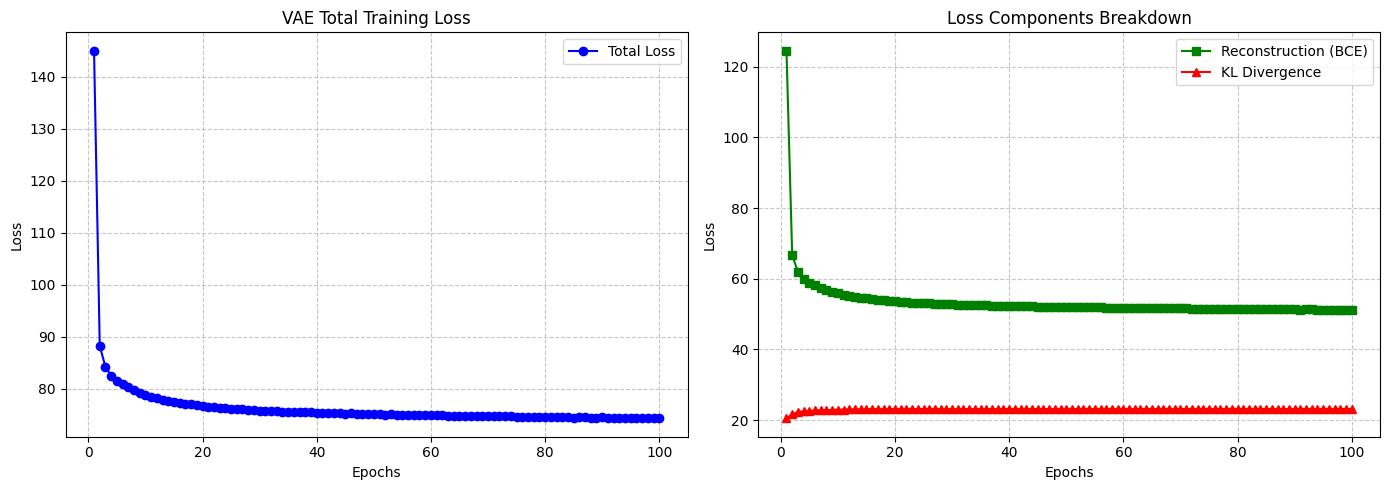

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.118700266..1.037117].


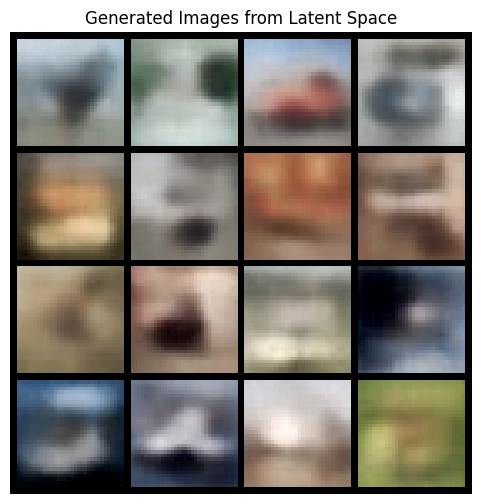

In [14]:
# Visualize the loss curves
plot_vae_history(cifar_history_FP)

# Generate 16 new CIFAR-10-like images
generate_vae_images(model=vae_net_cifar, num_images=16, device=device)

# Visualize the 2D latent space directly
# plot_2d_latent_space(model=vae_net, test_loader=mnist_test, device=device)

# plot_latent_space(vae_net_cifar)

# Mixed Training

In [15]:
# MNIST VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net = ConvVAE(
    in_channels=mnist_in_channels,     # 1
    input_size=mnist_input_size,       # (28, 28)
    latent_dim=LATENT_DIM
).to(device)

# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_optimizer = optim.Adam(vae_net.parameters(), lr=1e-3)

# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS

# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")

mnist_history_MP = train_vae(
    model=vae_net,
    train_loader=mnist_train,
    epochs=test_epochs,
    optimizer=vae_optimizer,
    device=device,
    dataset_name="mnist",
    use_mixed_precision=True  # Mixed Precision (FP16/FP32)
)

print("Test training complete!")

save_trained_vae(
    model=mnist_history_MP["model"],
    optimizer=mnist_history_MP["optimizer"],
    history=mnist_history_MP,
    save_dir="./saved_models/VAE/MNIST",
    run_name="vae_mnist_MP",
    model_config=mnist_config,
    extra_info={"dataset": "mnist", "precision": "mixed"}
)

Starting VAE training for 100 epochs...
Epoch [1/100] | Loss: 170.6652 | BCE: 144.6681 | KLD: 25.9971
Epoch [2/100] | Loss: 120.4203 | BCE: 89.8163 | KLD: 30.6040
Epoch [3/100] | Loss: 112.8162 | BCE: 83.1835 | KLD: 29.6328
Epoch [4/100] | Loss: 109.9448 | BCE: 80.8171 | KLD: 29.1277
Epoch [5/100] | Loss: 108.2697 | BCE: 79.4892 | KLD: 28.7805
Epoch [6/100] | Loss: 107.1059 | BCE: 78.5810 | KLD: 28.5249
Epoch [7/100] | Loss: 106.3865 | BCE: 77.9885 | KLD: 28.3980
Epoch [8/100] | Loss: 105.6597 | BCE: 77.4678 | KLD: 28.1919
Epoch [9/100] | Loss: 105.1956 | BCE: 77.0901 | KLD: 28.1054
Epoch [10/100] | Loss: 104.7831 | BCE: 76.7713 | KLD: 28.0118
Epoch [11/100] | Loss: 104.3878 | BCE: 76.4750 | KLD: 27.9128
Epoch [12/100] | Loss: 104.0355 | BCE: 76.2318 | KLD: 27.8038
Epoch [13/100] | Loss: 103.7867 | BCE: 76.0213 | KLD: 27.7654
Epoch [14/100] | Loss: 103.5302 | BCE: 75.8395 | KLD: 27.6907
Epoch [15/100] | Loss: 103.2667 | BCE: 75.6512 | KLD: 27.6156
Epoch [16/100] | Loss: 103.0537 | BCE:

('saved_models/VAE/MNIST/vae_mnist_MP.pt',
 'saved_models/VAE/MNIST/vae_mnist_MP_history.json')

In [16]:
# Fashion MNIST VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net = ConvVAE(
    in_channels=fashion_mnist_in_channels,     # 1
    input_size=fashion_mnist_input_size,       # (28, 28)
    latent_dim=LATENT_DIM
).to(device)

# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_optimizer = optim.Adam(vae_net.parameters(), lr=1e-3)

# 4. Set your test epochs
test_epochs = prod_EPOCHS#dev_EPOCHS

# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")

fmnist_history_MP = train_vae(
    model=vae_net,
    train_loader=fashion_mnist_train,
    epochs=test_epochs,
    optimizer=vae_optimizer,
    device=device,
    dataset_name="fmnist",
    use_mixed_precision=True  # Mixed Precision (FP16/FP32)
)

print("Test training complete!")

save_trained_vae(
    model=fmnist_history_MP["model"],
    optimizer=fmnist_history_MP["optimizer"],
    history=fmnist_history_MP,
    save_dir="./saved_models/VAE/FMNIST",
    run_name="vae_fashionmnist_MP",
    model_config=fashion_mnist_config,
    extra_info={"dataset": "fashion-mnist", "precision": "mixed"}
)

Starting VAE training for 100 epochs...
Epoch [1/100] | Loss: 303.9346 | BCE: 282.4792 | KLD: 21.4554
Epoch [2/100] | Loss: 259.3141 | BCE: 239.0055 | KLD: 20.3086
Epoch [3/100] | Loss: 252.1859 | BCE: 232.9974 | KLD: 19.1885
Epoch [4/100] | Loss: 249.4203 | BCE: 230.4631 | KLD: 18.9572
Epoch [5/100] | Loss: 247.7808 | BCE: 228.9475 | KLD: 18.8333
Epoch [6/100] | Loss: 246.6338 | BCE: 227.9232 | KLD: 18.7107
Epoch [7/100] | Loss: 245.8267 | BCE: 227.1818 | KLD: 18.6450
Epoch [8/100] | Loss: 245.0980 | BCE: 226.5290 | KLD: 18.5690
Epoch [9/100] | Loss: 244.5263 | BCE: 225.9946 | KLD: 18.5317
Epoch [10/100] | Loss: 244.0504 | BCE: 225.5944 | KLD: 18.4561
Epoch [11/100] | Loss: 243.6314 | BCE: 225.2315 | KLD: 18.3999
Epoch [12/100] | Loss: 243.2276 | BCE: 224.9002 | KLD: 18.3273
Epoch [13/100] | Loss: 242.9954 | BCE: 224.6666 | KLD: 18.3288
Epoch [14/100] | Loss: 242.6288 | BCE: 224.3733 | KLD: 18.2555
Epoch [15/100] | Loss: 242.3868 | BCE: 224.1779 | KLD: 18.2089
Epoch [16/100] | Loss: 2

('saved_models/VAE/FMNIST/vae_fashionmnist_MP.pt',
 'saved_models/VAE/FMNIST/vae_fashionmnist_MP_history.json')

In [17]:
# cifar10 VAE Training
# 2. Instantiate the VAE model and send it to your device (CPU/GPU)
vae_net_cifar = ConvVAE(
    in_channels=cifar10_in_channels,   # 3
    input_size=cifar10_input_size,     # (32, 32)
    latent_dim=2*LATENT_DIM                     # CIFAR needs a richer latent space
).to(device)  
# 3. Set up the optimizer 
# Adam with a learning rate of 1e-3 is the standard starting point for VAEs
vae_cifar_optimizer = optim.Adam(vae_net_cifar.parameters(), lr=1e-3)
# 4. Set your test epochs
test_epochs = prod_EPOCHS #dev_EPOCHS
# 5. Run the training loop!
print(f"Starting VAE training for {test_epochs} epochs...")
cifar_history_MP = train_vae(
    model=vae_net_cifar,
    train_loader=cifar10_train,
    epochs=test_epochs,
    optimizer=vae_cifar_optimizer,
    device=device,
    dataset_name="cifar10",
    use_mixed_precision=True   # Enables modern AMP (FP16/FP32)
)
print("Test training complete!")

save_trained_vae(
    model=cifar_history_MP["model"],
    optimizer=cifar_history_MP["optimizer"],
    history=cifar_history_MP,
    save_dir="./saved_models/VAE/CIFAR",
    run_name="vae_cifar10_MP",
    model_config=cifar_config,
    extra_info={"dataset": "cifar10", "precision": "mixed"}
)

Starting VAE training for 100 epochs...
Epoch [1/100] | Loss: 177.1545 | BCE: 159.2794 | KLD: 17.8752
Epoch [2/100] | Loss: 87.0729 | BCE: 66.2778 | KLD: 20.7951
Epoch [3/100] | Loss: 82.9910 | BCE: 61.2652 | KLD: 21.7258
Epoch [4/100] | Loss: 81.3170 | BCE: 59.1838 | KLD: 22.1332
Epoch [5/100] | Loss: 80.5889 | BCE: 58.3305 | KLD: 22.2585
Epoch [6/100] | Loss: 79.9534 | BCE: 57.6786 | KLD: 22.2748
Epoch [7/100] | Loss: 79.4814 | BCE: 57.1853 | KLD: 22.2961
Epoch [8/100] | Loss: 79.1795 | BCE: 56.8070 | KLD: 22.3725
Epoch [9/100] | Loss: 78.7832 | BCE: 56.3466 | KLD: 22.4365
Epoch [10/100] | Loss: 78.5409 | BCE: 56.0316 | KLD: 22.5093
Epoch [11/100] | Loss: 78.1420 | BCE: 55.5824 | KLD: 22.5596
Epoch [12/100] | Loss: 77.9326 | BCE: 55.3114 | KLD: 22.6212
Epoch [13/100] | Loss: 77.6465 | BCE: 55.0213 | KLD: 22.6252
Epoch [14/100] | Loss: 77.4338 | BCE: 54.7455 | KLD: 22.6883
Epoch [15/100] | Loss: 77.2649 | BCE: 54.5564 | KLD: 22.7085
Epoch [16/100] | Loss: 77.0779 | BCE: 54.3852 | KLD:

('saved_models/VAE/CIFAR/vae_cifar10_MP.pt',
 'saved_models/VAE/CIFAR/vae_cifar10_MP_history.json')